<a href="https://colab.research.google.com/github/laribar/Datathon/blob/main/Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas pyarrow


In [ ]:
import json
from pathlib import Path
import pandas as pd

# O Google Colab armazena os arquivos enviados diretamente no diretório /content/.
# Você pode acessá-los diretamente, sem a necessidade de montar o Google Drive.
DATA_DIR = Path('/content/')

def load_json_flex(path: Path) -> pd.DataFrame:
    """
    Carrega dados JSON de um arquivo em um DataFrame do pandas.
    Tenta diferentes formatos JSON: NDJSON, array/dict e linhas JSON.
    """
    # 1) NDJSON (Newline Delimited JSON)
    try:
        df = pd.read_json(path, lines=True)
        if not df.empty:
            return df
    except Exception:
        pass

    # 2) array/dict
    try:
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        if isinstance(data, list):
            return pd.json_normalize(data, max_level=1)
        if isinstance(data, dict):
            for k, v in data.items():
                if isinstance(v, list):
                    return pd.json_normalize(v, max_level=1)
            return pd.json_normalize(data, max_level=1)
    except Exception:
        pass

    # 3) linhas JSON
    try:
        with path.open("r", encoding="utf-8") as f:
            rows = [json.loads(line) for line in f if line.strip()]
        return pd.json_normalize(rows, max_level=1)
    except Exception as e:
        print(f"Erro ao processar o arquivo {path}: {e}")
        return pd.DataFrame() # Retorna um DataFrame vazio em caso de falha

In [ ]:
# Definimos o diretório de dados para a pasta padrão do Colab
DATA_DIR = Path('/content/')

# Seu código de carregamento
vagas_path = DATA_DIR / "vagas.json"
apps_path = DATA_DIR / "applicants.json"
pros_path = DATA_DIR / "prospects.json"

df_vagas = load_json_flex(vagas_path)
df_apps = load_json_flex(apps_path)
df_pros = load_json_flex(pros_path)

# Adicione esta verificação
if df_vagas.empty or df_apps.empty or df_pros.empty:
    print("Erro: Um ou mais DataFrames estão vazios. Verifique se os arquivos JSON foram carregados corretamente.")
else:
    print("Todos os arquivos foram carregados com sucesso! ✅")
    print(f"Shapes: vagas={df_vagas.shape}, applicants={df_apps.shape}, prospects={df_pros.shape}")

Todos os arquivos foram carregados com sucesso! ✅
Shapes: vagas=(1, 42243), applicants=(1, 297374), prospects=(1, 42666)


In [ ]:
# Célula 4 — Normalizar dados "largos" (colunas = ID.campo) para formato tabular

import pandas as pd
from pandas import json_normalize

def _ensure_series(df):
    if len(df) != 1:
        raise ValueError("Esperava 1 linha; recebi {}. Verifique o loader.".format(len(df)))
    return df.iloc[0]

def normalize_vagas(df_vagas_raw: pd.DataFrame) -> pd.DataFrame:
    """Converte colunas como '5185.informacoes_basicas', '5185.perfil_vaga', ... em linhas por job_id."""
    row = _ensure_series(df_vagas_raw)
    buckets = {}

    for col, val in row.items():
        if not isinstance(col, str) or "." not in col:
            # ignora colunas sem o padrão <id>.<campo>
            continue
        job_id, field = col.split(".", 1)
        rec = buckets.setdefault(job_id, {"job_id": job_id})

        # Se o valor for dict, achata mantendo prefixo do campo
        if isinstance(val, dict):
            flat = json_normalize(val, sep=".").iloc[0].to_dict()
            flat = {f"{field}.{k}": v for k, v in flat.items()}
            rec.update(flat)
        else:
            rec[field] = val

    df = pd.DataFrame.from_records(list(buckets.values()))
    # texto unificado da vaga (título/senioridade/descrição/requisitos/desejáveis, se existirem)
    def build_text(r):
        parts = []
        for c in [
            "informacoes_basicas.titulo_vaga",
            "informacoes_basicas.senioridade",
            "perfil_vaga.descricao",
            "perfil_vaga.requisitos",
            "perfil_vaga.desejaveis",
        ]:
            v = r.get(c)
            if isinstance(v, str) and v.strip():
                parts.append(" ".join(v.split()))
        return " | ".join(parts)
    df["vaga_text"] = df.apply(build_text, axis=1)
    return df

def normalize_prospects(df_pros_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Procura colunas '<job_id>.prospects' que contêm listas de candidatos.
    Explode em linhas: job_id, codigo (candidato), situacao_candidado, etc.
    """
    row = _ensure_series(df_pros_raw)
    rows = []
    for col, val in row.items():
        if not isinstance(col, str) or not col.endswith(".prospects"):
            continue
        job_id = col.split(".", 1)[0]
        if isinstance(val, list):
            for item in val:
                if isinstance(item, dict):
                    rec = {"job_id": job_id}
                    rec.update(item)
                    rows.append(rec)
    if not rows:
        return pd.DataFrame(columns=["job_id", "codigo", "situacao_candidado"])
    df = pd.DataFrame(rows)
    # padroniza chaves úteis
    if "codigo" in df.columns:
        df["applicant_id"] = df["codigo"].astype(str)
    elif "codigo_profissional" in df.columns:
        df["applicant_id"] = df["codigo_profissional"].astype(str)
    else:
        # tenta achar alguma coluna de id de candidato
        cand_col = next((c for c in df.columns if "codigo" in c or "id" in c), None)
        if cand_col:
            df["applicant_id"] = df[cand_col].astype(str)
    # status
    status_col = next(
        (c for c in ["situacao_candidado","situacao_candidato","status","etapa"] if c in df.columns),
        None
    )
    if status_col is None:
        df["status"] = None
        status_col = "status"
    else:
        df = df.rename(columns={status_col: "status"})
    # tipifica
    df["job_id"] = df["job_id"].astype(str)
    df["applicant_id"] = df["applicant_id"].astype(str)
    return df[["job_id","applicant_id","status"] + [c for c in df.columns if c not in ["job_id","applicant_id","status"]]]

def normalize_applicants(df_apps_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Converte colunas '<applicant_id>.<campo>' para linhas por candidato.
    Tenta extrair cv_pt e agrega demais campos.
    """
    row = _ensure_series(df_apps_raw)
    buckets = {}

    for col, val in row.items():
        if not isinstance(col, str) or "." not in col:
            continue
        app_id, field = col.split(".", 1)
        rec = buckets.setdefault(app_id, {"applicant_id": app_id})

        if isinstance(val, dict):
            flat = json_normalize(val, sep=".").iloc[0].to_dict()
            flat = {f"{field}.{k}": v for k, v in flat.items()}
            rec.update(flat)
        else:
            rec[field] = val

    df = pd.DataFrame.from_records(list(buckets.values()))

    # Escolhe um campo de CV principal
    def pick_cv(r):
        for c in ["cv_pt", "cv", "curriculo", "resumo"]:
            v = r.get(c)
            if isinstance(v, str) and v.strip():
                return " ".join(v.split())
        # tenta campos textuais que pareçam descrição/experiência
        texts = []
        for c, v in r.items():
            if isinstance(v, str) and any(k in c.lower() for k in ["resumo","experiencia","descricao","cv"]):
                v2 = v.strip()
                if v2:
                    texts.append(" ".join(v2.split()))
        return " | ".join(texts) if texts else None

    df["cv_text"] = df.apply(pick_cv, axis=1)
    return df

# ---- executar normalização
df_vagas_norm = normalize_vagas(df_vagas)
df_pros_norm  = normalize_prospects(df_pros)
df_apps_norm  = normalize_applicants(df_apps)

print("vagas_norm:", df_vagas_norm.shape)
print("prospects_norm:", df_pros_norm.shape)
print("applicants_norm:", df_apps_norm.shape)

display(df_vagas_norm.head(3))
display(df_pros_norm.head(3))
display(df_apps_norm[["applicant_id","cv_text"]].head(3))


vagas_norm: (14081, 46)
prospects_norm: (53759, 9)
applicants_norm: (42482, 59)


,job_id,informacoes_basicas.data_requicisao,informacoes_basicas.limite_esperado_para_contratacao,informacoes_basicas.titulo_vaga,informacoes_basicas.vaga_sap,informacoes_basicas.cliente,informacoes_basicas.solicitante_cliente,informacoes_basicas.empresa_divisao,informacoes_basicas.requisitante,informacoes_basicas.analista_responsavel,...,perfil_vaga.viagens_requeridas,perfil_vaga.equipamentos_necessarios,beneficios.valor_venda,beneficios.valor_compra_1,beneficios.valor_compra_2,informacoes_basicas.data_inicial,informacoes_basicas.data_final,perfil_vaga.habilidades_comportamentais_necessarias,informacoes_basicas.nome_substituto,vaga_text
0,5185,04-05-2021,00-00-0000,Operation Lead -,Não,"Morris, Moran and Dodson",Dra. Catarina Marques,Decision São Paulo,Maria Laura Nogueira,Srta. Bella Ferreira,...,,Nenhum -,-,R$,,NaN,NaN,NaN,NaN,Operation Lead -
1,5184,04-05-2021,00-00-0000,Consultor PP/QM Sênior,Não,"Morris, Moran and Dodson",Dra. Catarina Marques,Decision São Paulo,Maria Laura Nogueira,Yasmin da Rosa,...,,Nenhum -,-,R$,,NaN,NaN,NaN,NaN,Consultor PP/QM Sênior
2,5183,04-05-2021,00-00-0000,ANALISTA PL/JR C/ SQL,Não,"Morris, Moran and Dodson",Dra. Catarina Marques,Decision São Paulo,Maria Laura Nogueira,Ana Albuquerque,...,,Nenhum -,-,R$,,NaN,NaN,NaN,NaN,ANALISTA PL/JR C/ SQL


,job_id,applicant_id,status,nome,codigo,data_candidatura,ultima_atualizacao,comentario,recrutador
0,4530,25632,Encaminhado ao Requisitante,José Vieira,25632,25-03-2021,25-03-2021,"Encaminhado para - PJ R$ 72,00/hora",Ana Lívia Moreira
1,4530,25529,Encaminhado ao Requisitante,Srta. Isabela Cavalcante,25529,22-03-2021,23-03-2021,"encaminhado para - R$ 6.000,00 – CLT Full , n...",Ana Lívia Moreira
2,4531,25364,Contratado pela Decision,Sra. Yasmin Fernandes,25364,17-03-2021,12-04-2021,Data de Inicio: 12/04/2021,Juliana Cassiano


,applicant_id,cv_text
0,31000,assistente administrativo santosbatista itapec...
1,31001,formação acadêmica ensino médio (2º grau) em e...
2,31002,objetivo: área administrativa | financeira res...


In [ ]:
# Célula 5 — Gerar pares (vaga ↔ candidato) rotulados e salvar em disco

from pathlib import Path
import pandas as pd

# 1) mapeamento de status → label
LABEL_POS = {
    "Aprovado",
    "Contratado pela Decision",
    "Contratado como Hunting",
    # Inclua se quiser considerar como positivo:
    # "Documentação PJ",
}
LABEL_NEG = {
    "Não Aprovado pelo Cliente",
    "Não Aprovado pelo RH",
    "Não Aprovado pelo Requisitante",
    "Não Aprovado",
    "Desistiu",
    "Sem interesse nesta vaga",
}

def map_label(s):
    if not isinstance(s, str):
        return None
    s = s.strip()
    if s in LABEL_POS: return 1
    if s in LABEL_NEG: return 0
    return None  # neutro (vamos descartar do treino)

# 2) aplica rótulo e filtra neutros
df_pros_labeled = df_pros_norm.copy()
df_pros_labeled["label"] = df_pros_labeled["status"].map(map_label)
df_pros_labeled = df_pros_labeled.dropna(subset=["label"]).copy()
df_pros_labeled["label"] = df_pros_labeled["label"].astype(int)

# 3) seleciona textos principais
vagas_text = df_vagas_norm[["job_id", "vaga_text"]].drop_duplicates()
apps_text  = df_apps_norm[["applicant_id", "cv_text"]].drop_duplicates()

# 4) junta (job_id, applicant_id, status, label) → vaga_text, cv_text
pairs = (
    df_pros_labeled[["job_id","applicant_id","status","label"]]
    .merge(vagas_text, on="job_id", how="left")
    .merge(apps_text, on="applicant_id", how="left")
)

# 5) limpeza final: remover pares sem texto
pairs = pairs.fillna({"vaga_text": "", "cv_text": ""})
pairs = pairs[(pairs["vaga_text"].str.len() > 0) & (pairs["cv_text"].str.len() > 0)].copy()

# 6) salvar
out_dir = Path("data/processed")
out_dir.mkdir(parents=True, exist_ok=True)
pairs_path = out_dir / "pairs.parquet"
pairs_sample_path = out_dir / "pairs_sample.csv"

pairs.to_parquet(pairs_path, index=False)
pairs.head(200).to_csv(pairs_sample_path, index=False, encoding="utf-8")

# 7) sanity check
n_total = len(pairs)
n_pos = int((pairs["label"]==1).sum())
n_neg = int((pairs["label"]==0).sum())
print("Pares tot.:", n_total, "| +:", n_pos, "| -:", n_neg)
print("Arquivos salvos em:")
print(" -", pairs_path)
print(" -", pairs_sample_path)

pairs.head(5)


Pares tot.: 9778 | +: 2475 | -: 7303
Arquivos salvos em:
 - data/processed/pairs.parquet
 - data/processed/pairs_sample.csv


,job_id,applicant_id,status,label,vaga_text,cv_text
0,4531,25364,Contratado pela Decision,1,2021-2607395-PeopleSoft Application Engine-Dom...,área de atuação: lider de consultoria / gerenc...
1,4533,26338,Contratado pela Decision,1,2021-2605708-Microfocus Application Life Cycle...,"solteiro, brasileiro, 21/06/1987 habilitação c..."
2,4533,24645,Desistiu,0,2021-2605708-Microfocus Application Life Cycle...,analista de teste/qa profissional hands on sem...
3,4534,26205,Desistiu,0,2021-2605711-Microfocus QTP - UFT Automation T...,"idade: 37 anos 172 apto.2703, vila maria josé ..."
4,4534,26003,Não Aprovado pelo Cliente,0,2021-2605711-Microfocus QTP - UFT Automation T...,solteira – 40 anos – brasileira itaquaquecetub...


A PARTIR DAQUI COMEÇA A PREPARAÇÃO PRO MODELO

In [ ]:
# 1) Instalação das bibliotecas
# Note: o "!" antes do comando indica que você está executando um comando de shell
!pip install sentence-transformers xgboost

In [ ]:


# 2) Importações
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# ============================
# Configurações
# ============================
# Defina os caminhos para o ambiente do Colab
# O arquivo de dados está na raiz do ambiente de execução
from pathlib import Path

# Cria a estrutura de pastas
Path("/content/data/processed").mkdir(parents=True, exist_ok=True)

# Agora, o caminho para os dados é o mesmo do seu ambiente local
DATA_PATH = Path('/content/data/processed/pairs.parquet')

# O diretório para salvar o modelo
MODEL_DIR = Path('/content/models/')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "modelo_match_xgboost.pkl"
ENCODER_NAME = "sbert_encoder"

SBERT_MODEL = "all-MiniLM-L6-v2"

# ============================
# 1) Carregar dataset
# ============================
print("🔹 Carregando dataset...")
# Verifique se o arquivo existe antes de tentar carregar
if not DATA_PATH.exists():
    print(f"Erro: O arquivo {DATA_PATH} não foi encontrado. Por favor, verifique se você o salvou na pasta /content/.")
    # Adicione uma mensagem de saída para interromper a execução, se necessário
else:
    df = pd.read_parquet(DATA_PATH)

    # Garantir que não haja NaN
    df = df.fillna({"vaga_text": "", "cv_text": ""})

    # ============================
    # 2) Gerar embeddings
    # ============================
    print("🔹 Carregando SentenceTransformer...")
    encoder = SentenceTransformer(SBERT_MODEL)

    print("🔹 Gerando embeddings das vagas...")
    vaga_embeddings = encoder.encode(df["vaga_text"].tolist(), show_progress_bar=True)

    print("🔹 Gerando embeddings dos candidatos...")
    cv_embeddings = encoder.encode(df["cv_text"].tolist(), show_progress_bar=True)

    # ============================
    # 3) Criar features combinadas
    # ============================
    print("🔹 Combinando embeddings...")
    features = np.hstack([
        vaga_embeddings,
        cv_embeddings,
        np.abs(vaga_embeddings - cv_embeddings),
        vaga_embeddings * cv_embeddings
    ])

    labels = df["label"].values

    # ============================
    # 4) Dividir treino/teste
    # ============================
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # ============================
    # 5) Treinar e Otimizar modelo XGBoost
    # ============================
    print("🔹 Otimizando modelo XGBoost...")

    pos_count = np.sum(y_train == 1)
    neg_count = np.sum(y_train == 0)
    scale_pos_weight = neg_count / pos_count

    param_distributions = {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 10],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )

    search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_distributions,
        n_iter=20,
        scoring='f1',
        cv=5,
        verbose=1,
        random_state=42
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print(f"✅ Melhor F1-score: {search.best_score_:.4f}")
    print(f"✅ Melhores parâmetros: {search.best_params_}")

    # ============================
    # 6) Avaliar o melhor modelo
    # ============================
    y_pred = best_model.predict(X_test)
    print("\n📊 Classification Report (XGBoost Otimizado):")
    print(classification_report(y_test, y_pred, digits=3))

    print("📌 Matriz de Confusão:")
    print(confusion_matrix(y_test, y_pred))

    # ============================
    # 7) Salvar o melhor modelo e encoder
    # ============================
    print("💾 Salvando o melhor modelo e encoder...")
    joblib.dump(best_model, MODEL_DIR / MODEL_NAME)
    encoder.save(MODEL_DIR / ENCODER_NAME)

    print(f"✅ Modelo salvo em: {MODEL_DIR / MODEL_NAME}")
    print(f"✅ Encoder salvo em: {MODEL_DIR / ENCODER_NAME}")


🔹 Carregando dataset...
🔹 Carregando SentenceTransformer...
🔹 Gerando embeddings das vagas...


Batches:   0%|          | 0/306 [00:00<?, ?it/s]

🔹 Gerando embeddings dos candidatos...


Batches:   0%|          | 0/306 [00:00<?, ?it/s]

🔹 Combinando embeddings...
🔹 Otimizando modelo XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:47:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:56:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:05:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:14:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:23:08] WARNING: /w

✅ Melhor F1-score: 0.5522
✅ Melhores parâmetros: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

📊 Classification Report (XGBoost Otimizado):
              precision    recall  f1-score   support

           0      0.849     0.868     0.858      1461
           1      0.583     0.545     0.564       495

    accuracy                          0.786      1956
   macro avg      0.716     0.707     0.711      1956
weighted avg      0.782     0.786     0.784      1956

📌 Matriz de Confusão:
[[1268  193]
 [ 225  270]]
💾 Salvando o melhor modelo e encoder...
✅ Modelo salvo em: /content/models/modelo_match_xgboost.pkl
✅ Encoder salvo em: /content/models/sbert_encoder


📊 Gerando gráficos de desempenho...


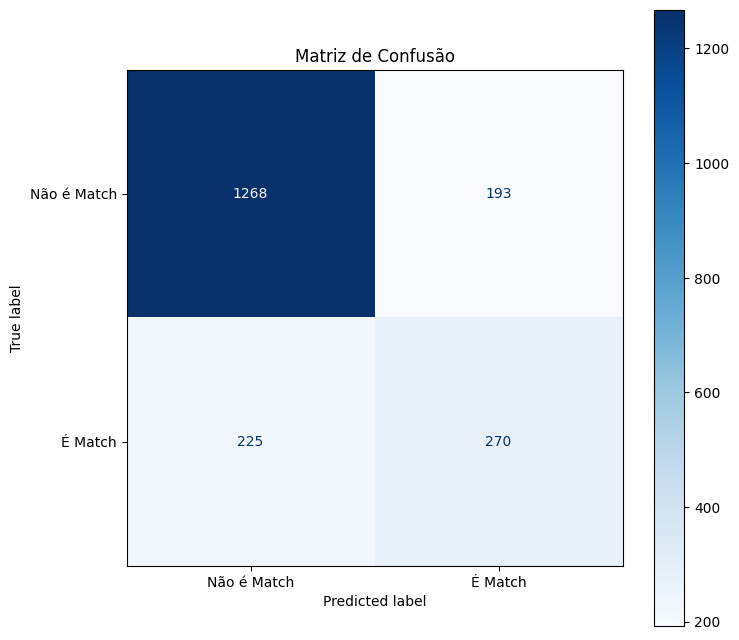

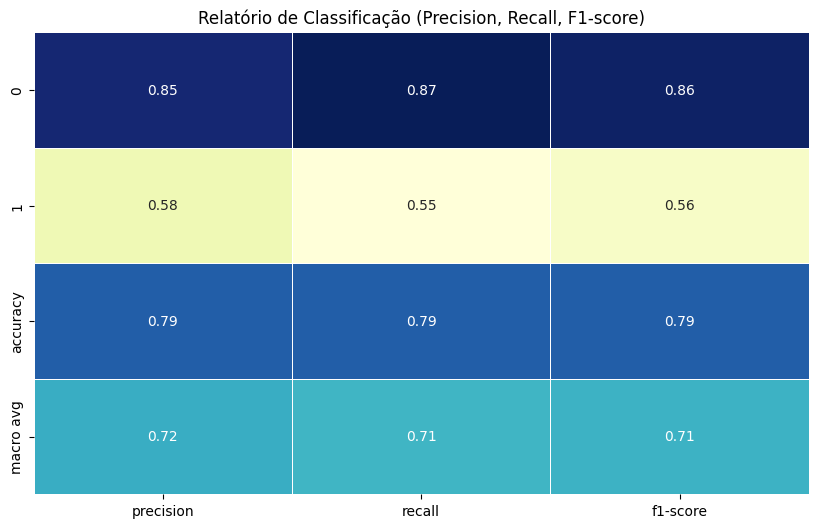

✅ Gráficos gerados com sucesso!


In [19]:
# Importa as bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ============================
# Geração dos Gráficos
# ============================
print("📊 Gerando gráficos de desempenho...")

# 1) Gráfico da Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 8))
# Cria o display da matriz de confusão
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Não é Match", "É Match"],
    cmap=plt.cm.Blues,
    ax=ax
)
ax.set_title("Matriz de Confusão")
plt.show()

# 2) Gráfico do Relatório de Classificação (Precision, Recall, F1-score)
# Para este gráfico, vamos criar um DataFrame com os dados do relatório
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df_report.iloc[:-1, :-1], # Ignora a linha 'accuracy' e a coluna 'support'
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=.5,
    cbar=False
)
ax.set_title("Relatório de Classificação (Precision, Recall, F1-score)")
plt.show()

print("✅ Gráficos gerados com sucesso!")